In [8]:
import pandas as pd
import seaborn as sns

In [1]:
import pysam
from statistics import mean, median

def bam_identity_stats(
    bam_path,
    min_identity=0.99,
    max_softclip_frac=0.01,
    mapq_on="aligned"  # "aligned" or "fully_mapped"
):
    """
    mapq_on:
      - "aligned": average MAPQ over primary mapped (non-secondary/supp) reads
      - "fully_mapped": average MAPQ only over reads passing the softclip filter
    """
    bam = pysam.AlignmentFile(bam_path, "rb")

    total_reads = 0
    aligned_reads = 0
    fully_mapped_reads = 0
    high_identity_reads = 0

    mapqs_aligned = []
    mapqs_fully = []

    for read in bam.fetch(until_eof=True):
        total_reads += 1

        # Skip unmapped, secondary, supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        aligned_reads += 1
        mapqs_aligned.append(read.mapping_quality)

        aligned_len = 0
        softclip_len = 0

        # Parse CIGAR
        for op, length in read.cigartuples or []:
            if op in {0, 7, 8, 1}:   # M, =, X, I (consume read)
                aligned_len += length
            elif op == 4:            # S
                softclip_len += length
            # D (2) excluded

        if aligned_len == 0:
            continue

        read_len = aligned_len + softclip_len

        # Fully-mapped criterion (allow small soft clipping)
        if softclip_len / read_len > max_softclip_frac:
            continue

        fully_mapped_reads += 1
        mapqs_fully.append(read.mapping_quality)

        # Compute identity (requires NM)
        if not read.has_tag("NM"):
            continue

        nm = read.get_tag("NM")  # mismatches + indels
        identity = 1 - (nm / aligned_len)

        if identity >= min_identity:
            high_identity_reads += 1

    bam.close()

    # Choose which set of reads to average MAPQ over
    chosen_mapqs = mapqs_aligned if mapq_on == "aligned" else mapqs_fully

    def safe_mean(x):
        return float(mean(x)) if x else float("nan")

    def safe_median(x):
        return float(median(x)) if x else float("nan")

    return {
        "total_reads": total_reads,
        "aligned_reads": aligned_reads,
        "fully_mapped_reads": fully_mapped_reads,
        "high_identity_reads": high_identity_reads,

        # proportions
        "pct_aligned": aligned_reads / total_reads if total_reads else float("nan"),
        "pct_fully_mapped": fully_mapped_reads / total_reads if total_reads else float("nan"),
        "pct_high_identity_total": high_identity_reads / total_reads if total_reads else float("nan"),
        "pct_high_identity_aligned": high_identity_reads / aligned_reads if aligned_reads else float("nan"),
        "pct_high_identity_fully_mapped": high_identity_reads / fully_mapped_reads if fully_mapped_reads else float("nan"),

        # MAPQ summaries
        "mapq_on": mapq_on,
        "mean_mapq": safe_mean(chosen_mapqs),
        "median_mapq": safe_median(chosen_mapqs),
        "mean_mapq_aligned": safe_mean(mapqs_aligned),
        "mean_mapq_fully_mapped": safe_mean(mapqs_fully),
    }


In [2]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment_ref/linear_mapping/results/S1/S1.sorted.bam"
)

In [3]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_aligned': 0.9607490638528814,
 'pct_fully_mapped': 0.8891949114480392,
 'pct_high_identity_total': 0.6221904802214213,
 'pct_high_identity_aligned': 0.647609769949978,
 'pct_high_identity_fully_mapped': 0.6997233927128467,
 'mapq_on': 'aligned',
 'mean_mapq': 45.782013680114716,
 'median_mapq': 60.0,
 'mean_mapq_aligned': 45.782013680114716,
 'mean_mapq_fully_mapped': 46.64571390829656}

In [ ]:
total_reads = 78818808
paired = 78239732
mapped = 76304172

In [9]:
76304172/ 78818808

0.9680959904899856

In [7]:
78239732/78818808

0.9926530733628958

In [8]:
75233677/78818808

0.9545142702487964

In [4]:
78239732 + 579076

78818808

In [5]:
75725096 + 579076

76304172

In [ ]:
stats_linear

In [10]:
sample_align = pd.read_csv('/home/tbellagio/scratch/pang/pang_experiment_ref/pangenomes/set_02_rep3/mapping/seedmix/S1/S1.alignment_stats.tsv', nrows= 10000, sep = '\t')

<Axes: xlabel='mapping_quality', ylabel='Count'>

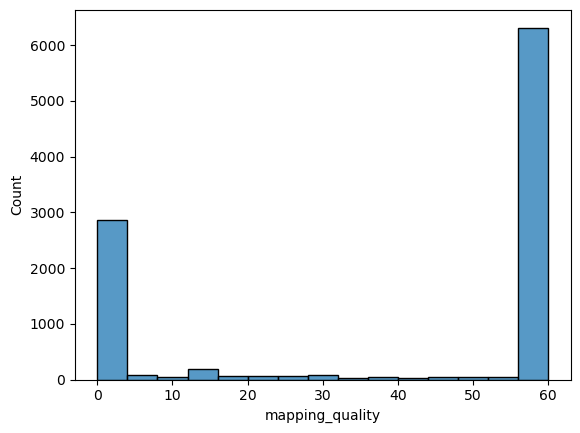

In [11]:
sns.histplot(sample_align['mapping_quality'])